In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

In [ ]:
from datasets import load_dataset
ds = load_dataset("pietrolesci/nli_fever")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
from datasets import concatenate_datasets
df = concatenate_datasets([ds['train'], ds['test'], ds['dev']])
df=df.to_pandas()
df=df[df['label']!=-1]

In [ ]:
df

,cid,fid,premise,hypothesis,verifiable,fever_gold_label,label
0,75397,f3680d64-bcdf-426f-a1ad-e8ae25ea9ba0,Nikolaj Coster-Waldau worked with the Fox Broa...,The Fox Broadcasting Company ( often shortened...,1.0,SUPPORTS,0
1,150448,fef1e0e5-4961-4cb1-a2df-72cf857c072d,Roman Atwood is a content creator.,Roman Atwood . He is best known for his vlogs ...,1.0,SUPPORTS,0
2,150448,74e0bfe1-5e7e-4b6f-9d6c-a55e2e72567e,Roman Atwood is a content creator.,"Roman Atwood . His vlogging channel , `` Roman...",1.0,SUPPORTS,0
3,214861,12af19b6-a930-4de8-8453-a02a7566f950,"History of art includes architecture, dance, s...",History of art . The subsequent expansion of t...,1.0,SUPPORTS,0
4,156709,9e514c12-f223-41d1-8820-7403def61479,Adrienne Bailon is an accountant.,Adrienne Eliza Houghton ( née Bailon ; born O...,1.0,REFUTES,2
...,...,...,...,...,...,...,...
248337,8538,1ca0c95b-92a2-42ee-afd6-148049e755ab,Hermit crabs are arachnids.,,NaN,REFUTES,2
248338,145641,51f46cb3-08e5-440c-8868-2adc0fc01f4c,Michael Hutchence died on a boat.,Michael Hutchence . On the morning of 22 Novem...,NaN,REFUTES,2
248339,87517,ebd2bfe5-3e4b-482e-8bfd-38909d122fe5,The Cyclades are located to the southeast of G...,"The Cyclades ( [ ˈsɪklədiːz ] Κυκλάδες , [ ci...",NaN,SUPPORTS,0
248340,111816,d5d6416f-df9d-4cb0-b29c-3fd3e40ed546,Theresa May worked the docks.,,NaN,NOT ENOUGH INFO,1


In [ ]:
for i in range(5):
    print("Evidence:")
    print(df.iloc[i]['premise'])
    print()
    print("Claim:")
    print(df.iloc[i]['hypothesis'])
    print()
    print("Label:", df.iloc[i]['fever_gold_label'])
    print("-"*80)

Evidence:
Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.

Claim:
The Fox Broadcasting Company ( often shortened to Fox and stylized as FOX ) is an American English language commercial broadcast television network that is owned by the Fox Entertainment Group subsidiary of 21st Century Fox . Nikolaj Coster-Waldau . He then played Detective John Amsterdam in the short-lived Fox television series New Amsterdam ( 2008 ) , as well as appearing as Frank Pike in the 2009 Fox television film Virtuality , originally intended as a pilot . He became widely known to a broad audience for his current role as Ser Jaime Lannister , in the HBO series Game of Thrones .

Label: SUPPORTS
--------------------------------------------------------------------------------
Evidence:
Roman Atwood is a content creator.

Claim:
Roman Atwood . He is best known for his vlogs , where he posts updates about his life on a daily basis . His vlogging channel , `` RomanAtwoodVlogs '' , has a total of 3.3 b

In [ ]:
df['label'].value_counts()

,count
label,
0,130260
2,55779
1,42305


In [ ]:
df['text'] = df['premise'] + " [SEP] " + df['hypothesis']

In [ ]:
df['text']

,text
0,Nikolaj Coster-Waldau worked with the Fox Broa...
1,Roman Atwood is a content creator. [SEP] Roman...
2,Roman Atwood is a content creator. [SEP] Roman...
3,"History of art includes architecture, dance, s..."
4,Adrienne Bailon is an accountant. [SEP] Adrien...
...,...
248337,Hermit crabs are arachnids. [SEP]
248338,Michael Hutchence died on a boat. [SEP] Michae...
248339,The Cyclades are located to the southeast of G...
248340,Theresa May worked the docks. [SEP]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidfvectoriser=TfidfVectorizer(max_features=10000)
tfidf_embeddings=tfidfvectoriser.fit_transform(df['text'])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(tfidf_embeddings,df['label'],test_size=0.2,random_state=42,stratify=df['label'])

In [ ]:
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
def performance_metrics(y_test,y_pred):
  print('Accuracy:',accuracy_score(y_test,y_pred))
  print(classification_report(y_test,y_pred))

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(class_weight='balanced')
lr_model.fit(x_train,y_train)
y_pred=lr_model.predict(x_test)
performance_metrics(y_test,y_pred)

Accuracy: 0.5824738881954936
              precision    recall  f1-score   support

           0       0.77      0.57      0.65     26052
           1       0.36      0.58      0.45      8461
           2       0.54      0.62      0.58     11156

    accuracy                           0.58     45669
   macro avg       0.56      0.59      0.56     45669
weighted avg       0.64      0.58      0.60     45669



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


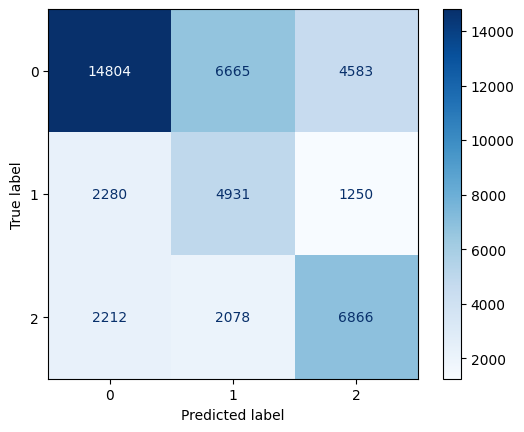

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
conf_matr=confusion_matrix(y_test,y_pred)
cm=ConfusionMatrixDisplay(conf_matr)
cm.plot(cmap=plt.cm.Blues)

In [ ]:
from sklearn.svm import LinearSVC
svm=LinearSVC(class_weight='balanced')
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
performance_metrics(y_test,y_pred)

Accuracy: 0.658061266942565
              precision    recall  f1-score   support

           0       0.73      0.78      0.75     26052
           1       0.46      0.42      0.44      8461
           2       0.62      0.56      0.59     11156

    accuracy                           0.66     45669
   macro avg       0.60      0.59      0.59     45669
weighted avg       0.65      0.66      0.65     45669



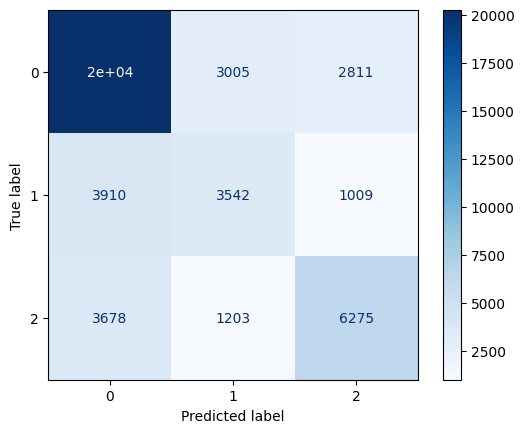

In [ ]:
conf_matr=confusion_matrix(y_test,y_pred)
cm=ConfusionMatrixDisplay(conf_matr)
cm.plot(cmap=plt.cm.Blues)

In [ ]:
from datasets import Dataset
import transformers
from transformers.models.auto.tokenization_auto import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments
from transformers import Trainer
import torch
import accelerate

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

In [ ]:
# ====================================
# SAMPLE DATA
# ====================================

df_small = df.sample(
    n=10000,
    random_state=42
)

train_df, test_df = train_test_split(
    df_small,
    test_size=0.2,
    stratify=df_small["label"],
    random_state=42
)

In [ ]:
# ====================================
# HF DATASETS
# ====================================

train_dataset = Dataset.from_pandas(
    train_df[["premise", "hypothesis", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["premise", "hypothesis", "label"]],
    preserve_index=False
)

In [ ]:
# ====================================
# TOKENIZER
# ====================================

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# ====================================
# TOKENIZATION
# ====================================

def tokenize_function(examples):
    return tokenizer(
        examples["premise"],
        examples["hypothesis"],
        truncation=True,
        max_length=64
    )


In [ ]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# ====================================
# LABEL COLUMN
# ====================================

train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label",
    "labels"
)


In [ ]:
# ====================================
# TORCH FORMAT
# ====================================

train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)


In [ ]:
# ====================================
# DYNAMIC PADDING
# ====================================

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
# ====================================
# MODEL
# ====================================

# --- Fix for ImportError: AutoModelForSequenceClassification requires PyTorch ---
# The error indicates that PyTorch is not found or is incompatible with
# the current transformers version. This can be caused by:
# 1. An incompatibility between PyTorch (compiled with NumPy 1.x) and the
#    currently installed NumPy 2.4.4.
# 2. The 'transformers' library requiring a PyTorch version (>=2.4) that is
#    newer than the installed one (2.2.2) and possibly unreleased for CPU.
#
# To resolve these, we will:
# - Downgrade NumPy to version 1.x for compatibility with PyTorch.
# - Force-reinstall PyTorch and Torchvision to ensure they are correctly
#   set up after the NumPy change.
# - Install specific, stable versions of 'datasets', 'transformers', and
#   'accelerate' to avoid potential version conflicts and ensure compatibility
#   with PyTorch 2.2.2.
# A runtime restart is CRITICAL after executing this cell to apply changes fully.

# -----------------------------------------------------------------------------

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ====================================
# METRICS
# ====================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
# ====================================
# TRAINING ARGS
# ====================================

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)


In [ ]:
# ====================================
# TRAINER
# ====================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
!pip install --upgrade datasets transformers accelerate

In [ ]:
# ====================================
# TRAIN
# ====================================

# NOTE: This cell previously caused an ImportError.
# To fix this, a new cell will be added to ensure
# torch and torchvision are correctly installed.

# --- Fix for ImportError: cannot import name 'VideoReader' ---


# -----------------------------------------------------------

trainer.train()

# ====================================
# EVALUATE
# ====================================

results = trainer.evaluate()

print(results)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.654343,0.577058,0.798500,0.733220,0.747979,0.727478
2,0.528799,0.739053,0.804500,0.748492,0.755664,0.742621


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Precision,Recall
0.528799,0.577058,2,0.798500,0.733220,0.747979,0.727478


{'eval_loss': 0.5770582556724548, 'eval_accuracy': 0.7985, 'eval_macro_f1': 0.7332201488501925, 'eval_precision': 0.7479791771633656, 'eval_recall': 0.7274775643110499}


In [ ]:
# ====================================
# PREDICTIONS
# ====================================

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = test_df["label"].values

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=[
            "SUPPORTS",
            "NOT_ENOUGH_INFO",
            "REFUTES"
        ]
    )
)

                 precision    recall  f1-score   support

       SUPPORTS       0.86      0.91      0.89      1130
NOT_ENOUGH_INFO       0.65      0.48      0.55       383
        REFUTES       0.73      0.79      0.76       487

       accuracy                           0.80      2000
      macro avg       0.75      0.73      0.73      2000
   weighted avg       0.79      0.80      0.79      2000

